In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = 'Datathon_VinTelligence/data_clean/Dataset_1_Revenue_Core.csv'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path
path = Path('/content/drive/MyDrive/Datathon_VinTelligence/data/data_clean')
name  = 'Dataset_1_Revenue_Core.csv'
finalpath = path/name
df = pd.read_csv(finalpath)
df.head()

,date,Revenue,COGS,orders_n,mobile_orders,order_success_rate,items_n,qty_sold,premium_qty,total_discount_amount,total_lines,premium_ratio,gross_profit,discount_rate,avg_item_price,day_of_week,is_weekend,month
0,2012-07-04,5123547.94,3982991.19,162,69,0.827160,174,777,9,0.0,174,0.011583,1140556.75,0.0,6594.012793,Wednesday,0,7
1,2012-07-05,2751773.45,2150580.23,97,38,0.835052,103,428,13,0.0,103,0.030374,601193.22,0.0,6429.377220,Thursday,0,7
2,2012-07-06,3054029.42,2517632.84,93,42,0.741935,99,441,0,0.0,99,0.000000,536396.58,0.0,6925.236780,Friday,0,7
3,2012-07-07,2667930.94,2108246.62,73,34,0.753425,75,364,0,0.0,75,0.000000,559684.32,0.0,7329.480604,Saturday,1,7
4,2012-07-08,2360851.90,1808622.79,88,45,0.761364,94,394,0,0.0,94,0.000000,552229.11,0.0,5992.009898,Sunday,1,7


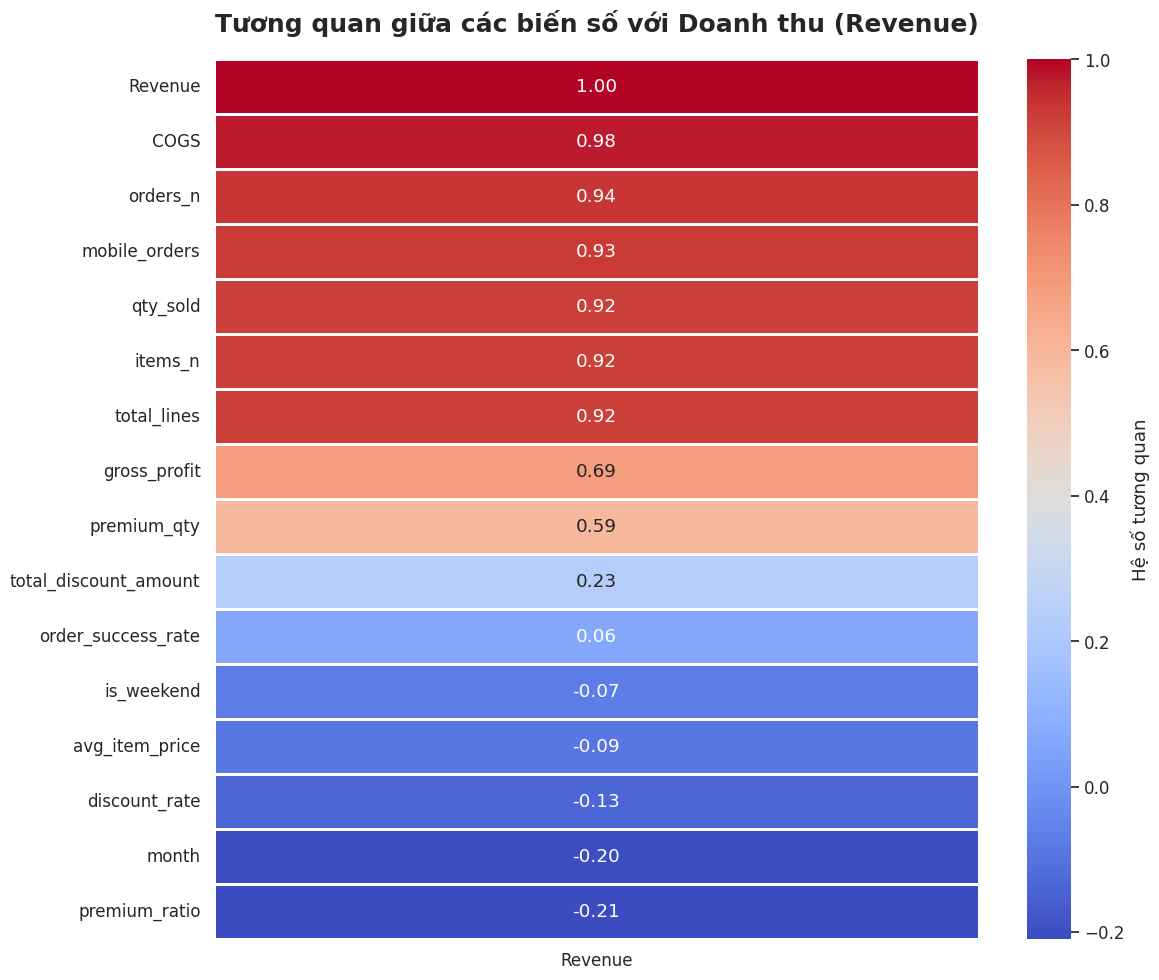

In [5]:
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
revenue_corr = corr[['Revenue']].sort_values(by='Revenue', ascending=False)
sns.heatmap(revenue_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, cbar_kws={'label': 'Hệ số tương quan'})
plt.title('Tương quan giữa các biến số với Doanh thu (Revenue)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

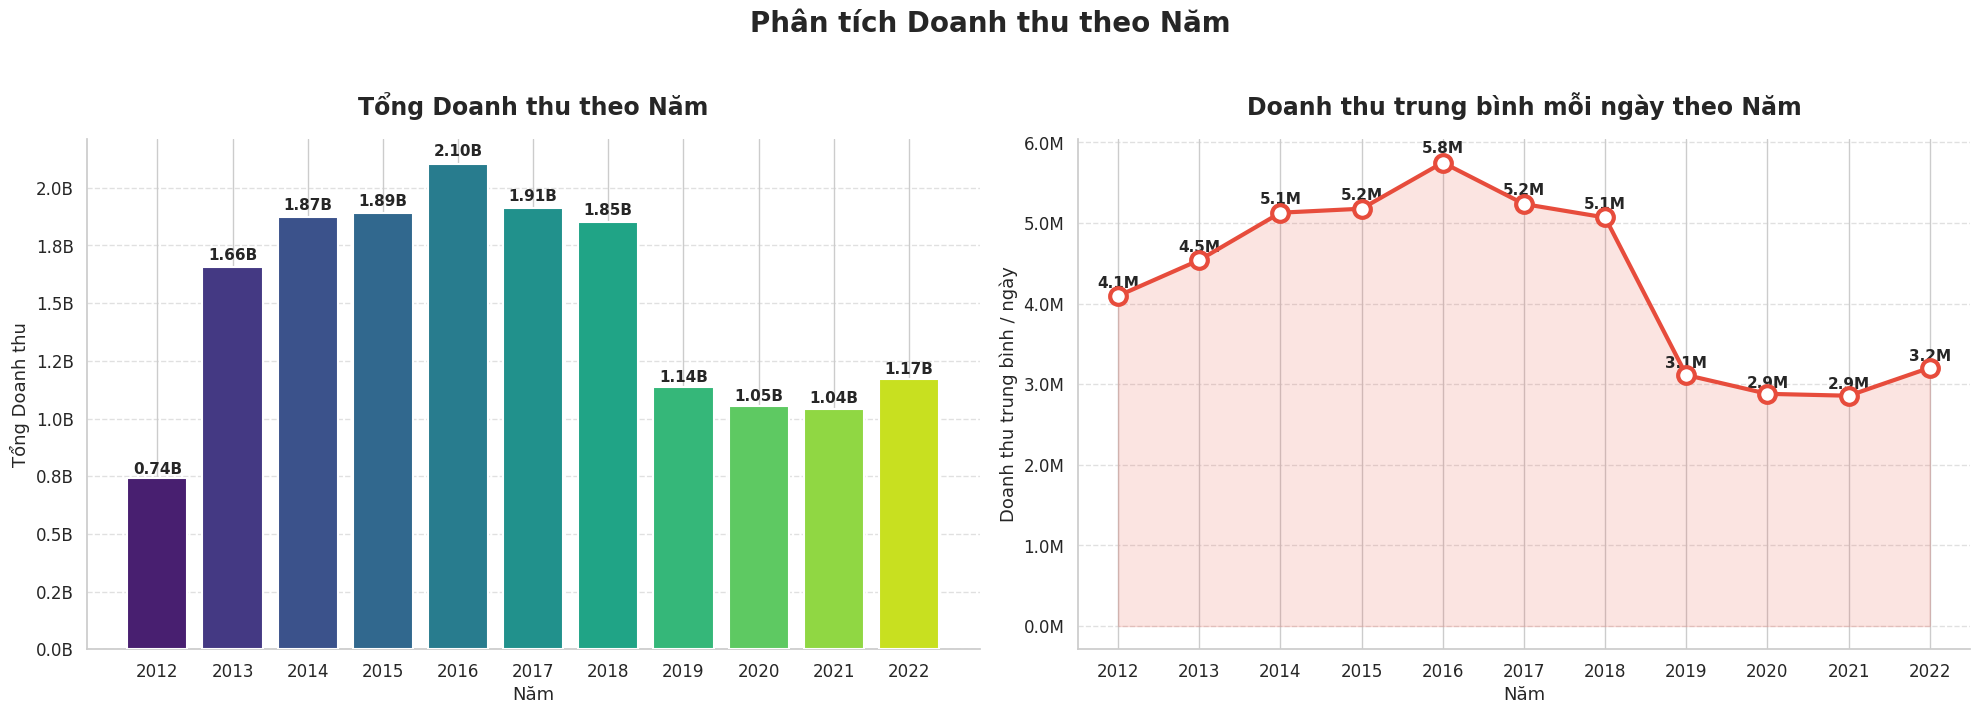

 year  total_revenue  avg_revenue
 2012   7.414977e+08 4.096673e+06
 2013   1.657169e+09 4.540190e+06
 2014   1.871846e+09 5.128345e+06
 2015   1.889934e+09 5.177901e+06
 2016   2.104641e+09 5.750384e+06
 2017   1.911164e+09 5.236067e+06
 2018   1.850122e+09 5.068829e+06
 2019   1.136801e+09 3.114524e+06
 2020   1.054512e+09 2.881181e+06
 2021   1.043040e+09 2.857643e+06
 2022   1.169749e+09 3.204791e+06


In [8]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
yearly_rev = df.groupby('year')['Revenue'].agg(['sum', 'mean']).reset_index()
yearly_rev.columns = ['year', 'total_revenue', 'avg_revenue']
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

bars = axes[0].bar(yearly_rev['year'], yearly_rev['total_revenue'],
                   color=sns.color_palette('viridis', len(yearly_rev)),
                   edgecolor='white', linewidth=1.5, zorder=3)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                 f'{h/1e9:.2f}B', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Tổng Doanh thu theo Năm', fontsize=17, fontweight='bold', pad=18)
axes[0].set_xlabel('Năm', fontsize=13)
axes[0].set_ylabel('Tổng Doanh thu', fontsize=13)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))
axes[0].set_xticks(yearly_rev['year'])
axes[0].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
sns.despine(ax=axes[0])
axes[1].plot(yearly_rev['year'], yearly_rev['avg_revenue'],
             marker='o', markersize=12, linewidth=3, color='#e74c3c',
             markerfacecolor='white', markeredgewidth=3, zorder=5)
axes[1].fill_between(yearly_rev['year'], yearly_rev['avg_revenue'],
                     alpha=0.15, color='#e74c3c')
for _, row in yearly_rev.iterrows():
    axes[1].text(row['year'], row['avg_revenue'] * 1.015,
                 f"{row['avg_revenue']/1e6:.1f}M",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Doanh thu trung bình mỗi ngày theo Năm', fontsize=17, fontweight='bold', pad=18)
axes[1].set_xlabel('Năm', fontsize=13)
axes[1].set_ylabel('Doanh thu trung bình / ngày', fontsize=13)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
axes[1].set_xticks(yearly_rev['year'])
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(ax=axes[1])
plt.suptitle('Phân tích Doanh thu theo Năm', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(yearly_rev.to_string(index=False))

### 2. Phân phối Doanh thu & Xu hướng Tổng quan theo Thời gian

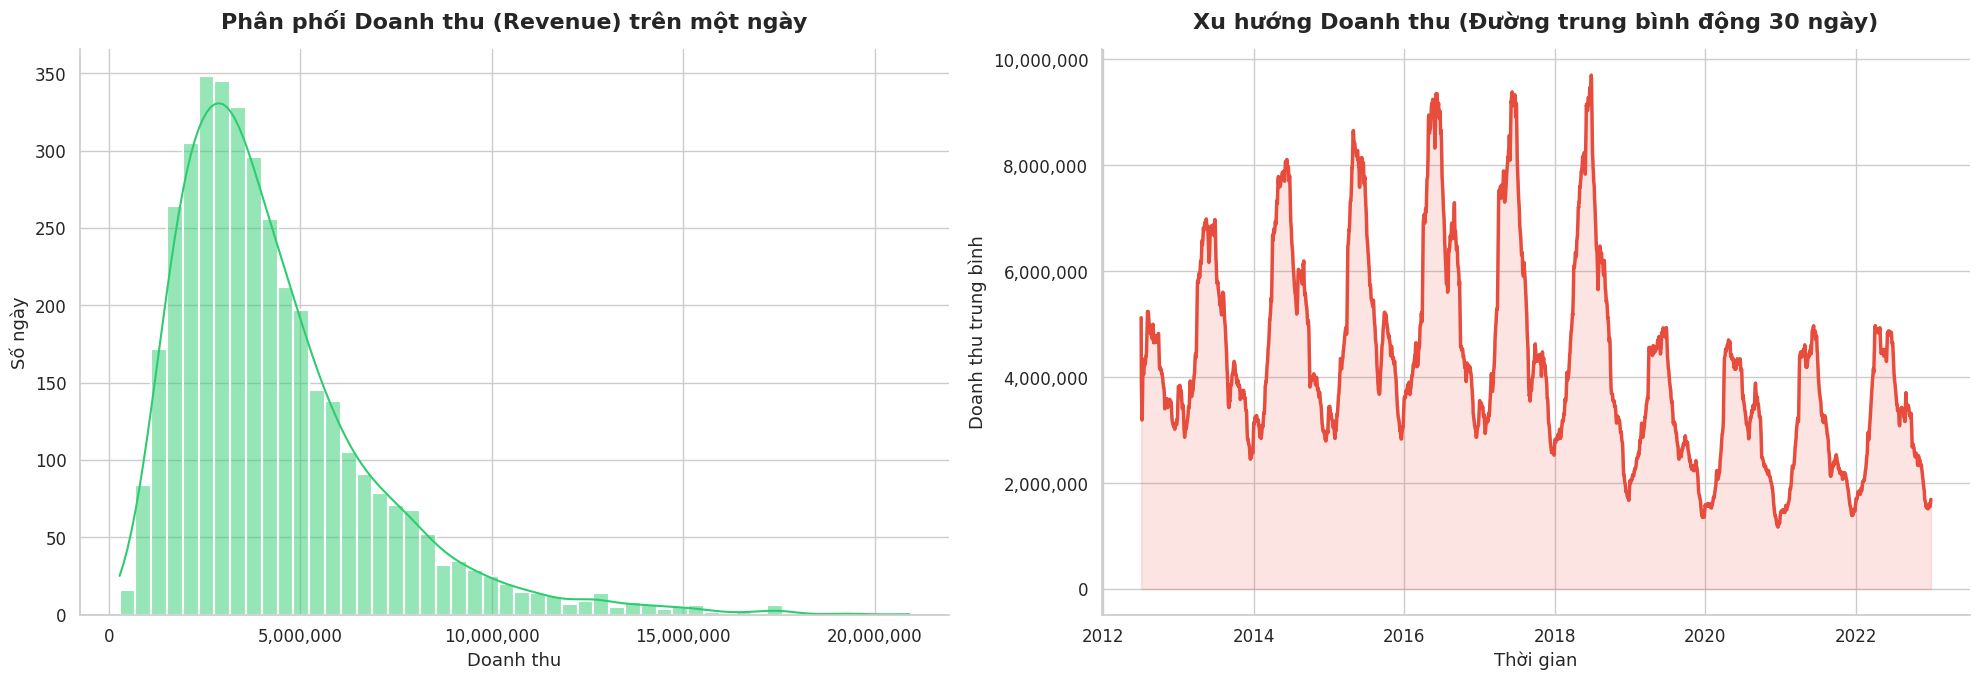

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.histplot(df['Revenue'], bins=50, kde=True, ax=axes[0], color='#2ecc71', edgecolor='white', linewidth=1.5)
axes[0].set_title('Phân phối Doanh thu (Revenue) trên một ngày', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Doanh thu', fontsize=13)
axes[0].set_ylabel('Số ngày', fontsize=13)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
if 'date' in df.columns:
    df_sorted = df.sort_values('date').set_index('date')
    df_sorted['Revenue_MA30'] = df_sorted['Revenue'].rolling(window=30, min_periods=1).mean()
    axes[1].plot(df_sorted.index, df_sorted['Revenue_MA30'], color='#e74c3c', linewidth=2.5)
    axes[1].set_title('Xu hướng Doanh thu (Đường trung bình động 30 ngày)', fontsize=16, fontweight='bold', pad=15)
    axes[1].set_xlabel('Thời gian', fontsize=13)
    axes[1].set_ylabel('Doanh thu trung bình', fontsize=13)
    axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    axes[1].fill_between(df_sorted.index, df_sorted['Revenue_MA30'], color='#e74c3c', alpha=0.15)
sns.despine()
plt.tight_layout()
plt.show()

### 3. Ảnh hưởng của Thời gian đến Hiệu suất Kinh doanh (Ngày & Mùa vụ)

/tmp/ipykernel_2461/3149525579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='is_weekend', y='Revenue', ax=axes[0], palette=['#3498db', '#e67e22'])
/tmp/ipykernel_2461/3149525579.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='Revenue', ax=axes[1], order=order_day, palette='viridis', errorbar=None)


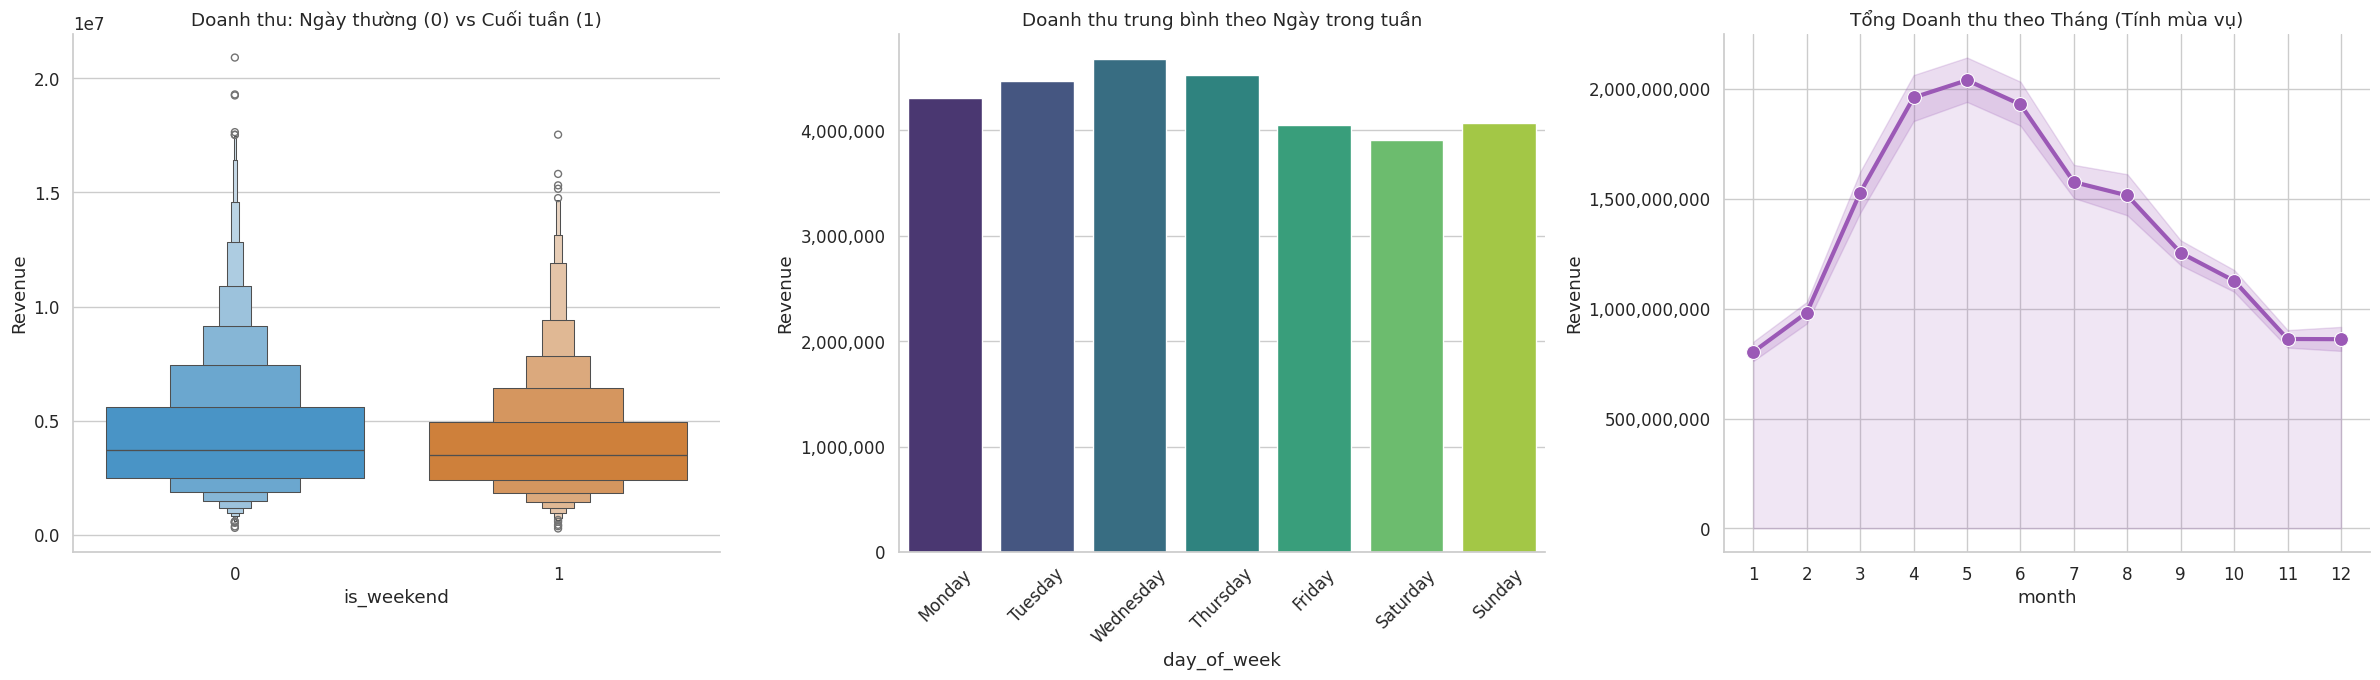

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.boxenplot(data=df, x='is_weekend', y='Revenue', ax=axes[0], palette=['#3498db', '#e67e22'])
axes[0].set_title('Doanh thu: Ngày thường (0) vs Cuối tuần (1)')

order_day = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='day_of_week', y='Revenue', ax=axes[1], order=order_day, palette='viridis', errorbar=None)
axes[1].set_title('Doanh thu trung bình theo Ngày trong tuần')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Revenue theo tháng
sns.lineplot(data=df, x='month', y='Revenue', estimator='sum', marker='o', markersize=10, ax=axes[2], color='#9b59b6', linewidth=3)
axes[2].set_title('Tổng Doanh thu theo Tháng (Tính mùa vụ)')
axes[2].set_xticks(range(1, 13))
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[2].fill_between(range(1, 13), df.groupby('month')['Revenue'].sum(), color='#9b59b6', alpha=0.15)

sns.despine()
plt.tight_layout()
plt.show()

### 4. Phân tích Cấu trúc Chi phí, Doanh thu & Lợi nhuận

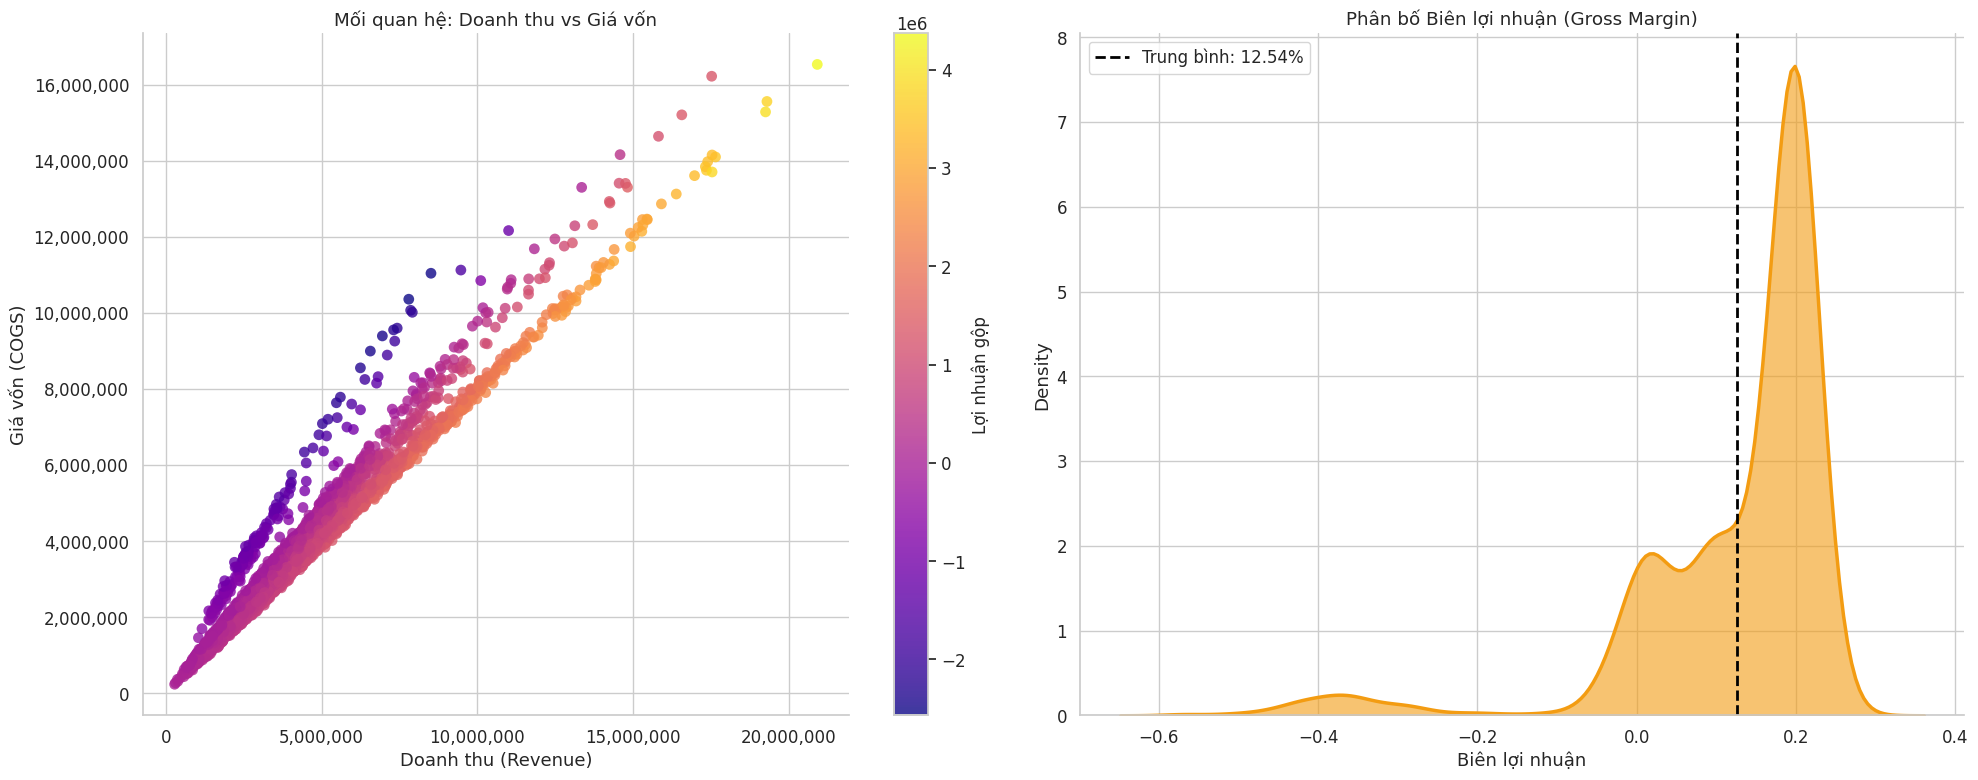

In [11]:
df['gross_margin'] = df['gross_profit'] / df['Revenue']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
scatter = axes[0].scatter(df['Revenue'], df['COGS'], c=df['gross_profit'], cmap='plasma', alpha=0.8, s=60, edgecolors='none')
axes[0].set_title('Mối quan hệ: Doanh thu vs Giá vốn' )
axes[0].set_xlabel('Doanh thu (Revenue)', fontsize=13)
axes[0].set_ylabel('Giá vốn (COGS)', fontsize=13)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Lợi nhuận gộp', fontsize=12)

sns.kdeplot(df['gross_margin'].dropna(), ax=axes[1], color='#f39c12', fill=True, alpha=0.6, linewidth=2.5)
axes[1].set_title('Phân bố Biên lợi nhuận (Gross Margin)')
axes[1].set_xlabel('Biên lợi nhuận', fontsize=13)
axes[1].axvline(df['gross_margin'].mean(), color='black', linestyle='--', linewidth=2, label=f"Trung bình: {df['gross_margin'].mean():.2%}")
axes[1].legend(fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

### 5. Khuyến mãi, Sản phẩm Cao cấp (Premium) & Quy mô giỏ hàng

In [ ]:
df['items_per_order'] = df['total_lines'] / df['orders_n']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.scatterplot(data=df, x='discount_rate', y='gross_profit', ax=axes[0], alpha=0.7, color='#1abc9c', s=70)
axes[0].set_title('Tỷ lệ giảm giá vs Lợi nhuận gộp')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.scatterplot(data=df, x='premium_ratio', y='avg_item_price', ax=axes[1], alpha=0.7, color='#d35400', s=70)
axes[1].set_title('Tỷ trọng Cao cấp vs Giá bán trung bình')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(df['items_per_order'].dropna(), bins=40, kde=True, ax=axes[2], color='#34495e', edgecolor='white')
axes[2].set_title('Phân bố Số sản phẩm / Đơn hàng')
sns.despine()
plt.tight_layout()
plt.show()

## 2. Phân tích Nguồn gốc Doanh thu (Revenue Drivers)

### 2.1  Revenue Decomposition: Đơn hàng × Giá cả

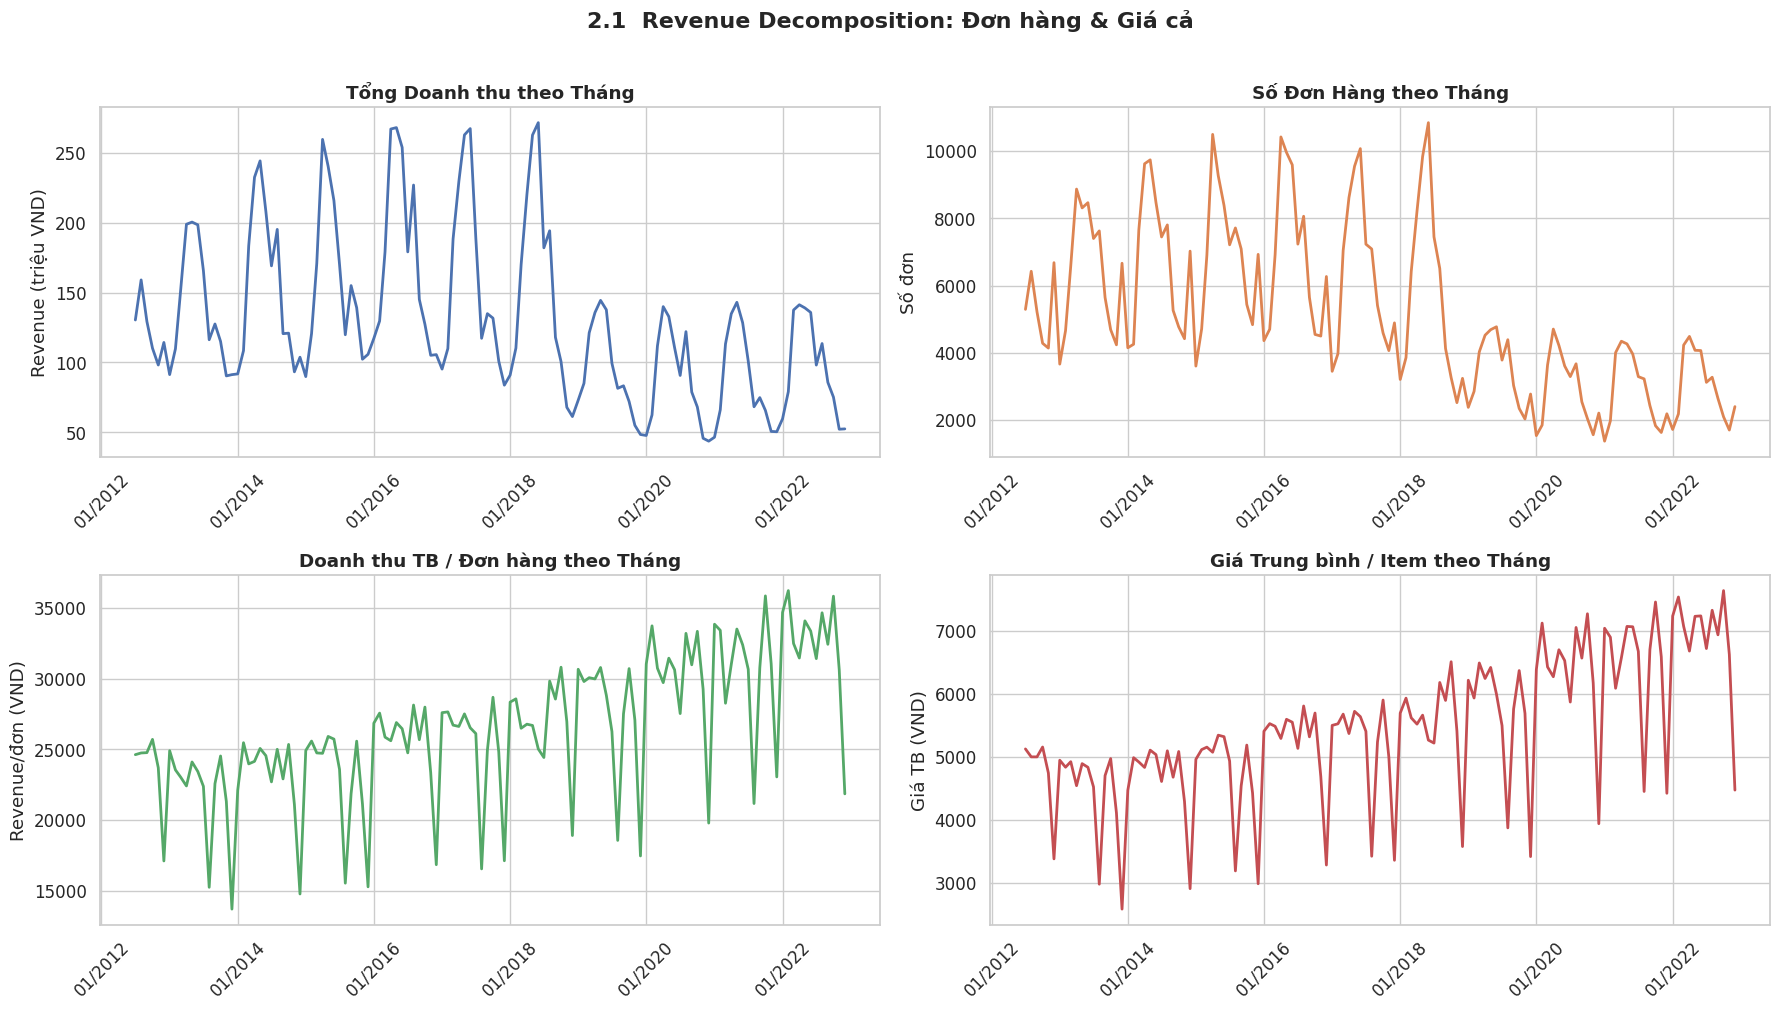

In [13]:

import matplotlib.dates as mdates
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
df['date'] = pd.to_datetime(df['date'])
df['year']  = df['date'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# (a) Revenue theo tháng
ax = axes[0, 0]
monthly = df.groupby(df['date'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly['date'] = monthly['date'].dt.to_timestamp()
ax.plot(monthly['date'], monthly['Revenue'] / 1e6, color=PALETTE[0], linewidth=2)
ax.set_title("Tổng Doanh thu theo Tháng", fontweight='bold')
ax.set_ylabel("Revenue (triệu VND)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
# (b) Số đơn hàng theo tháng
ax = axes[0, 1]
monthly_orders = df.groupby(df['date'].dt.to_period('M'))['orders_n'].sum().reset_index()
monthly_orders['date'] = monthly_orders['date'].dt.to_timestamp()
ax.plot(monthly_orders['date'], monthly_orders['orders_n'], color=PALETTE[1], linewidth=2)
ax.set_title("Số Đơn Hàng theo Tháng", fontweight='bold')
ax.set_ylabel("Số đơn")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
# (c) Revenue / đơn theo tháng
ax = axes[1, 0]
monthly_rpod = (
    df.groupby(df['date'].dt.to_period('M'))
      .apply(lambda g: g['Revenue'].sum() / g['orders_n'].sum())
      .reset_index()
)
monthly_rpod.columns = ['date', 'rev_per_order']
monthly_rpod['date'] = monthly_rpod['date'].dt.to_timestamp()
ax.plot(monthly_rpod['date'], monthly_rpod['rev_per_order'], color=PALETTE[2], linewidth=2)
ax.set_title("Doanh thu TB / Đơn hàng theo Tháng", fontweight='bold')
ax.set_ylabel("Revenue/đơn (VND)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
# (d) avg_item_price theo tháng
ax = axes[1, 1]
monthly_price = df.groupby(df['date'].dt.to_period('M'))['avg_item_price'].mean().reset_index()
monthly_price['date'] = monthly_price['date'].dt.to_timestamp()
ax.plot(monthly_price['date'], monthly_price['avg_item_price'], color=PALETTE[3], linewidth=2)
ax.set_title("Giá Trung bình / Item theo Tháng", fontweight='bold')
ax.set_ylabel("Giá TB (VND)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
fig.suptitle("2.1  Revenue Decomposition: Đơn hàng & Giá cả",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 2.2  Ảnh hưởng của Giảm giá (Discount) lên Doanh thu

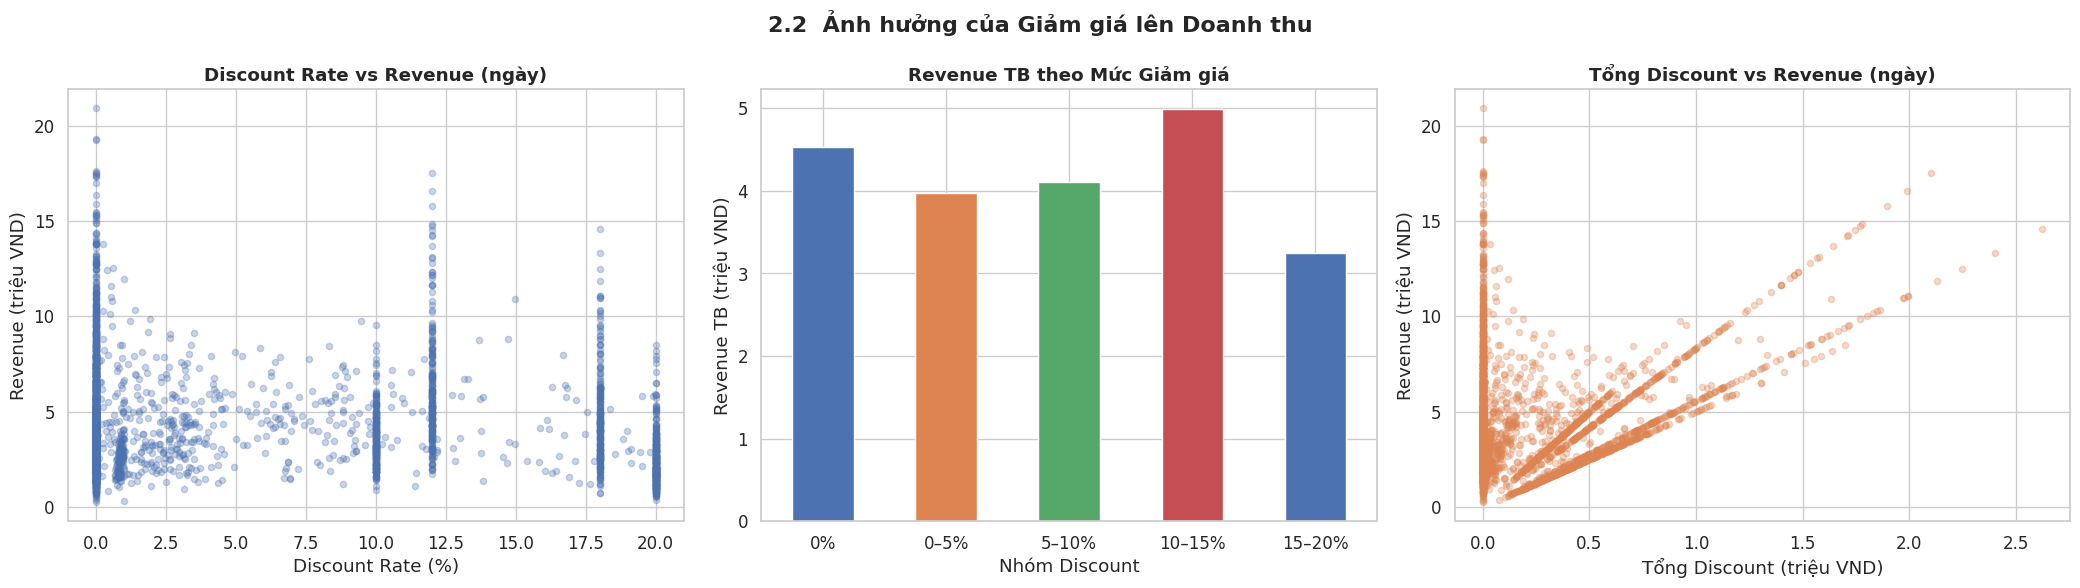

Tương quan Discount vs Revenue:
discount_rate           -0.134
total_discount_amount    0.232
Name: Revenue, dtype: float64


In [14]:

# 2.2  Discount Impact on Revenue
df['discount_bin'] = pd.cut(
    df['discount_rate'],
    bins=[-0.001, 0.001, 0.05, 0.10, 0.15, 0.201],
    labels=['0%', '0–5%', '5–10%', '10–15%', '15–20%']
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
# (a) Scatter: discount_rate vs Revenue
ax = axes[0]
ax.scatter(df['discount_rate'] * 100, df['Revenue'] / 1e6,
           alpha=0.3, color=PALETTE[0], s=20)
ax.set_xlabel("Discount Rate (%)"); ax.set_ylabel("Revenue (triệu VND)")
ax.set_title("Discount Rate vs Revenue (ngày)", fontweight='bold')
# (b) Revenue TB theo nhóm discount
ax = axes[1]
rev_by_disc = df.groupby('discount_bin', observed=True)['Revenue'].mean() / 1e6
rev_by_disc.plot(kind='bar', ax=ax,
                 color=PALETTE[:len(rev_by_disc)], edgecolor='white')
ax.set_xlabel("Nhóm Discount"); ax.set_ylabel("Revenue TB (triệu VND)")
ax.set_title("Revenue TB theo Mức Giảm giá", fontweight='bold')
ax.tick_params(axis='x', rotation=0)
# (c) Total discount amount vs Revenue
ax = axes[2]
ax.scatter(df['total_discount_amount'] / 1e6, df['Revenue'] / 1e6,
           alpha=0.3, color=PALETTE[1], s=20)
ax.set_xlabel("Tổng Discount (triệu VND)"); ax.set_ylabel("Revenue (triệu VND)")
ax.set_title("Tổng Discount vs Revenue (ngày)", fontweight='bold')
fig.suptitle("2.2  Ảnh hưởng của Giảm giá lên Doanh thu",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
corr_disc = df[['discount_rate', 'total_discount_amount', 'Revenue']].corr()
print("Tương quan Discount vs Revenue:")
print(corr_disc['Revenue'][['discount_rate', 'total_discount_amount']].round(3))


### 2.3  Đóng góp của Sản phẩm Premium

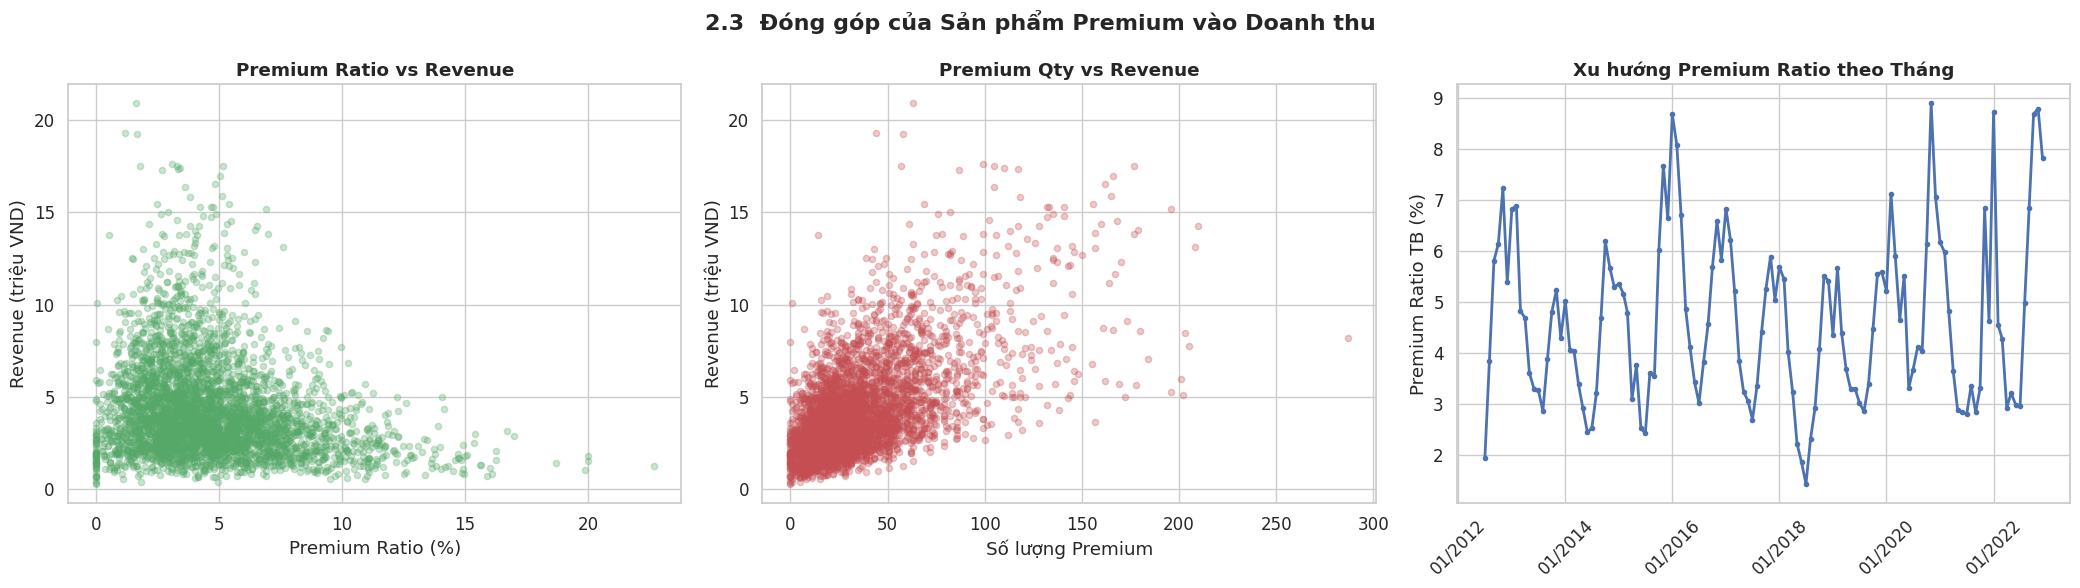

Tương quan Premium vs Revenue:
premium_ratio   -0.209
premium_qty      0.594
Name: Revenue, dtype: float64


In [15]:
# 2.3  Premium Product Contribution
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
# (a) premium_ratio vs Revenue
ax = axes[0]
ax.scatter(df['premium_ratio'] * 100, df['Revenue'] / 1e6,
           alpha=0.3, color=PALETTE[2], s=20)
ax.set_xlabel("Premium Ratio (%)"); ax.set_ylabel("Revenue (triệu VND)")
ax.set_title("Premium Ratio vs Revenue", fontweight='bold')
# (b) premium_qty vs Revenue
ax = axes[1]
ax.scatter(df['premium_qty'], df['Revenue'] / 1e6,
           alpha=0.3, color=PALETTE[3], s=20)
ax.set_xlabel("Số lượng Premium"); ax.set_ylabel("Revenue (triệu VND)")
ax.set_title("Premium Qty vs Revenue", fontweight='bold')
# (c) Trend premium_ratio theo tháng
ax = axes[2]
monthly_prem = df.groupby(df['date'].dt.to_period('M'))['premium_ratio'].mean().reset_index()
monthly_prem['date'] = monthly_prem['date'].dt.to_timestamp()
ax.plot(monthly_prem['date'], monthly_prem['premium_ratio'] * 100,
        color=PALETTE[0], linewidth=2, marker='o', markersize=3)
ax.set_ylabel("Premium Ratio TB (%)")
ax.set_title("Xu hướng Premium Ratio theo Tháng", fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle("2.3  Đóng góp của Sản phẩm Premium vào Doanh thu",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
corr_prem = df[['premium_ratio', 'premium_qty', 'Revenue']].corr()
print("Tương quan Premium vs Revenue:")
print(corr_prem['Revenue'][['premium_ratio', 'premium_qty']].round(3))


### 2.4  Tỷ lệ Đơn thành công & Revenue bị Mất

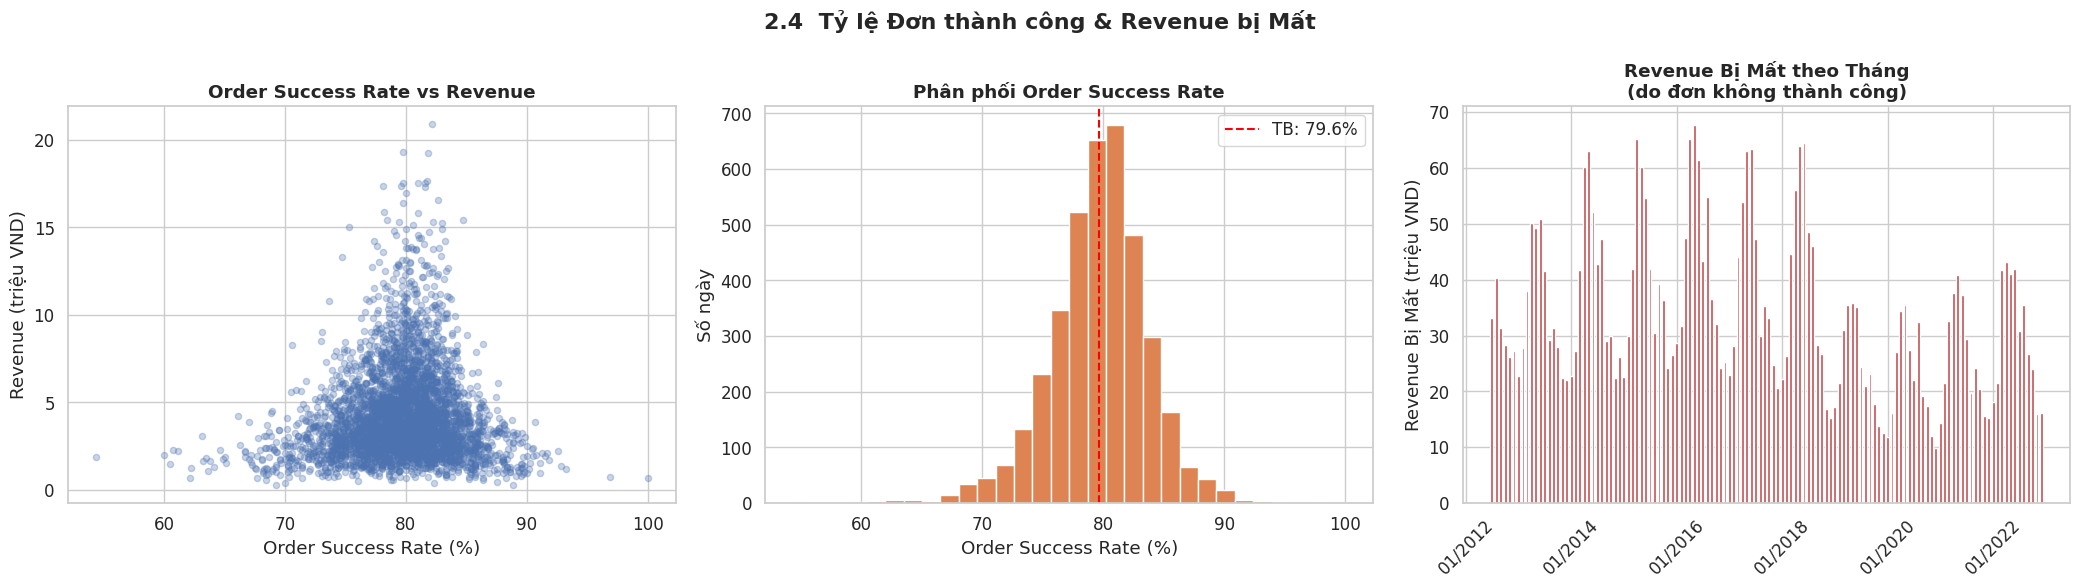

Tổng Revenue thực tế : 16.43 tỷ VND
Tổng Revenue bị mất  : 4.20 tỷ VND
Tỷ lệ Revenue bị mất : 20.4%


In [16]:

# 2.4  Order Success Rate & Lost Revenue
df['potential_revenue'] = df['Revenue'] / df['order_success_rate']
df['lost_revenue']      = df['potential_revenue'] - df['Revenue']
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# (a) Scatter
ax = axes[0]
ax.scatter(df['order_success_rate'] * 100, df['Revenue'] / 1e6,
           alpha=0.3, color=PALETTE[0], s=20)
ax.set_xlabel("Order Success Rate (%)"); ax.set_ylabel("Revenue (triệu VND)")
ax.set_title("Order Success Rate vs Revenue", fontweight='bold')
ax = axes[1]
ax.hist(df['order_success_rate'] * 100, bins=30,
        color=PALETTE[1], edgecolor='white')
ax.axvline(df['order_success_rate'].mean() * 100, color='red',
           linestyle='--',
           label=f"TB: {df['order_success_rate'].mean()*100:.1f}%")
ax.set_xlabel("Order Success Rate (%)"); ax.set_ylabel("Số ngày")
ax.set_title("Phân phối Order Success Rate", fontweight='bold')
ax.legend()
# (c) Lost revenue theo tháng
ax = axes[2]
monthly_lost = df.groupby(df['date'].dt.to_period('M'))['lost_revenue'].sum().reset_index()
monthly_lost['date'] = monthly_lost['date'].dt.to_timestamp()
ax.bar(monthly_lost['date'], monthly_lost['lost_revenue'] / 1e6,
       color=PALETTE[3], width=20)
ax.set_ylabel("Revenue Bị Mất (triệu VND)")
ax.set_title("Revenue Bị Mất theo Tháng\n(do đơn không thành công)", fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle("2.4  Tỷ lệ Đơn thành công & Revenue bị Mất",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

total_pot = df['potential_revenue'].sum()
total_lost = df['lost_revenue'].sum()
print(f"Tổng Revenue thực tế : {df['Revenue'].sum()/1e9:.2f} tỷ VND")
print(f"Tổng Revenue bị mất  : {total_lost/1e9:.2f} tỷ VND")
print(f"Tỷ lệ Revenue bị mất : {total_lost/total_pot*100:.1f}%")


### 2.5  Mobile vs Desktop Orders

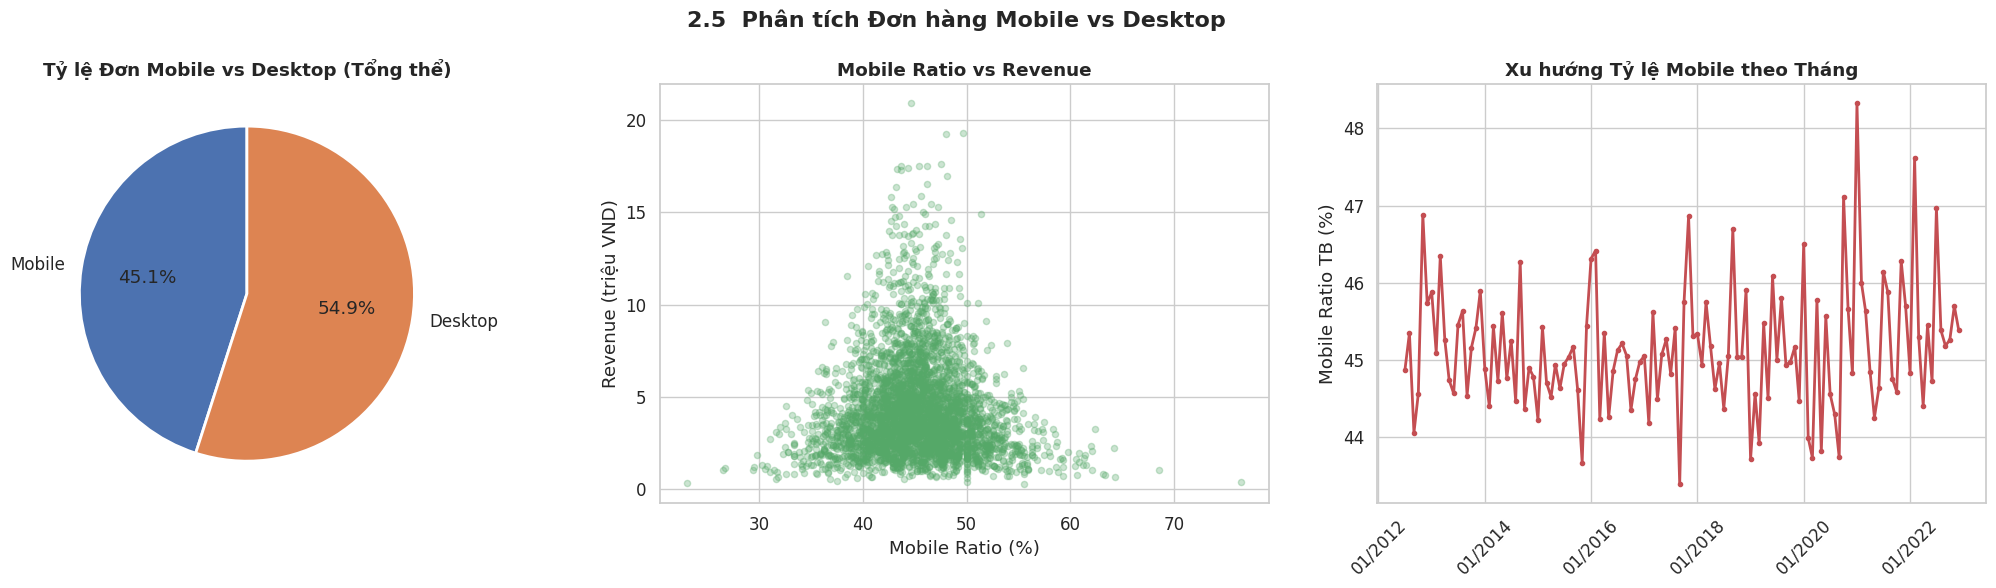

Tổng Mobile Orders : 291,482  (45.1%)
Tổng Desktop Orders: 355,463  (54.9%)
Tương quan Mobile Ratio vs Revenue: -0.036


In [17]:

# 2.5  Mobile vs Desktop Orders
df['mobile_ratio']   = df['mobile_orders'] / df['orders_n']
df['desktop_orders'] = df['orders_n'] - df['mobile_orders']
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# (a) Pie tổng thể
ax = axes[0]
total_mobile  = int(df['mobile_orders'].sum())
total_desktop = int(df['desktop_orders'].sum())
ax.pie([total_mobile, total_desktop],
       labels=['Mobile', 'Desktop'],
       colors=[PALETTE[0], PALETTE[1]],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("Tỷ lệ Đơn Mobile vs Desktop (Tổng thể)", fontweight='bold')

# (b) Mobile ratio vs Revenue
ax = axes[1]
ax.scatter(df['mobile_ratio'] * 100, df['Revenue'] / 1e6,
           alpha=0.3, color=PALETTE[2], s=20)
ax.set_xlabel("Mobile Ratio (%)"); ax.set_ylabel("Revenue (triệu VND)")
ax.set_title("Mobile Ratio vs Revenue", fontweight='bold')

# (c) Trend mobile ratio theo tháng
ax = axes[2]
monthly_mob = df.groupby(df['date'].dt.to_period('M'))['mobile_ratio'].mean().reset_index()
monthly_mob['date'] = monthly_mob['date'].dt.to_timestamp()
ax.plot(monthly_mob['date'], monthly_mob['mobile_ratio'] * 100,
        color=PALETTE[3], linewidth=2, marker='o', markersize=3)
ax.set_ylabel("Mobile Ratio TB (%)")
ax.set_title("Xu hướng Tỷ lệ Mobile theo Tháng", fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle("2.5  Phân tích Đơn hàng Mobile vs Desktop",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

grand = total_mobile + total_desktop
print(f"Tổng Mobile Orders : {total_mobile:,}  ({total_mobile/grand*100:.1f}%)")
print(f"Tổng Desktop Orders: {total_desktop:,}  ({total_desktop/grand*100:.1f}%)")
print(f"Tương quan Mobile Ratio vs Revenue: {df['mobile_ratio'].corr(df['Revenue']):.3f}")


### 2.6  Biên lợi nhuận gộp (Gross Profit Margin)

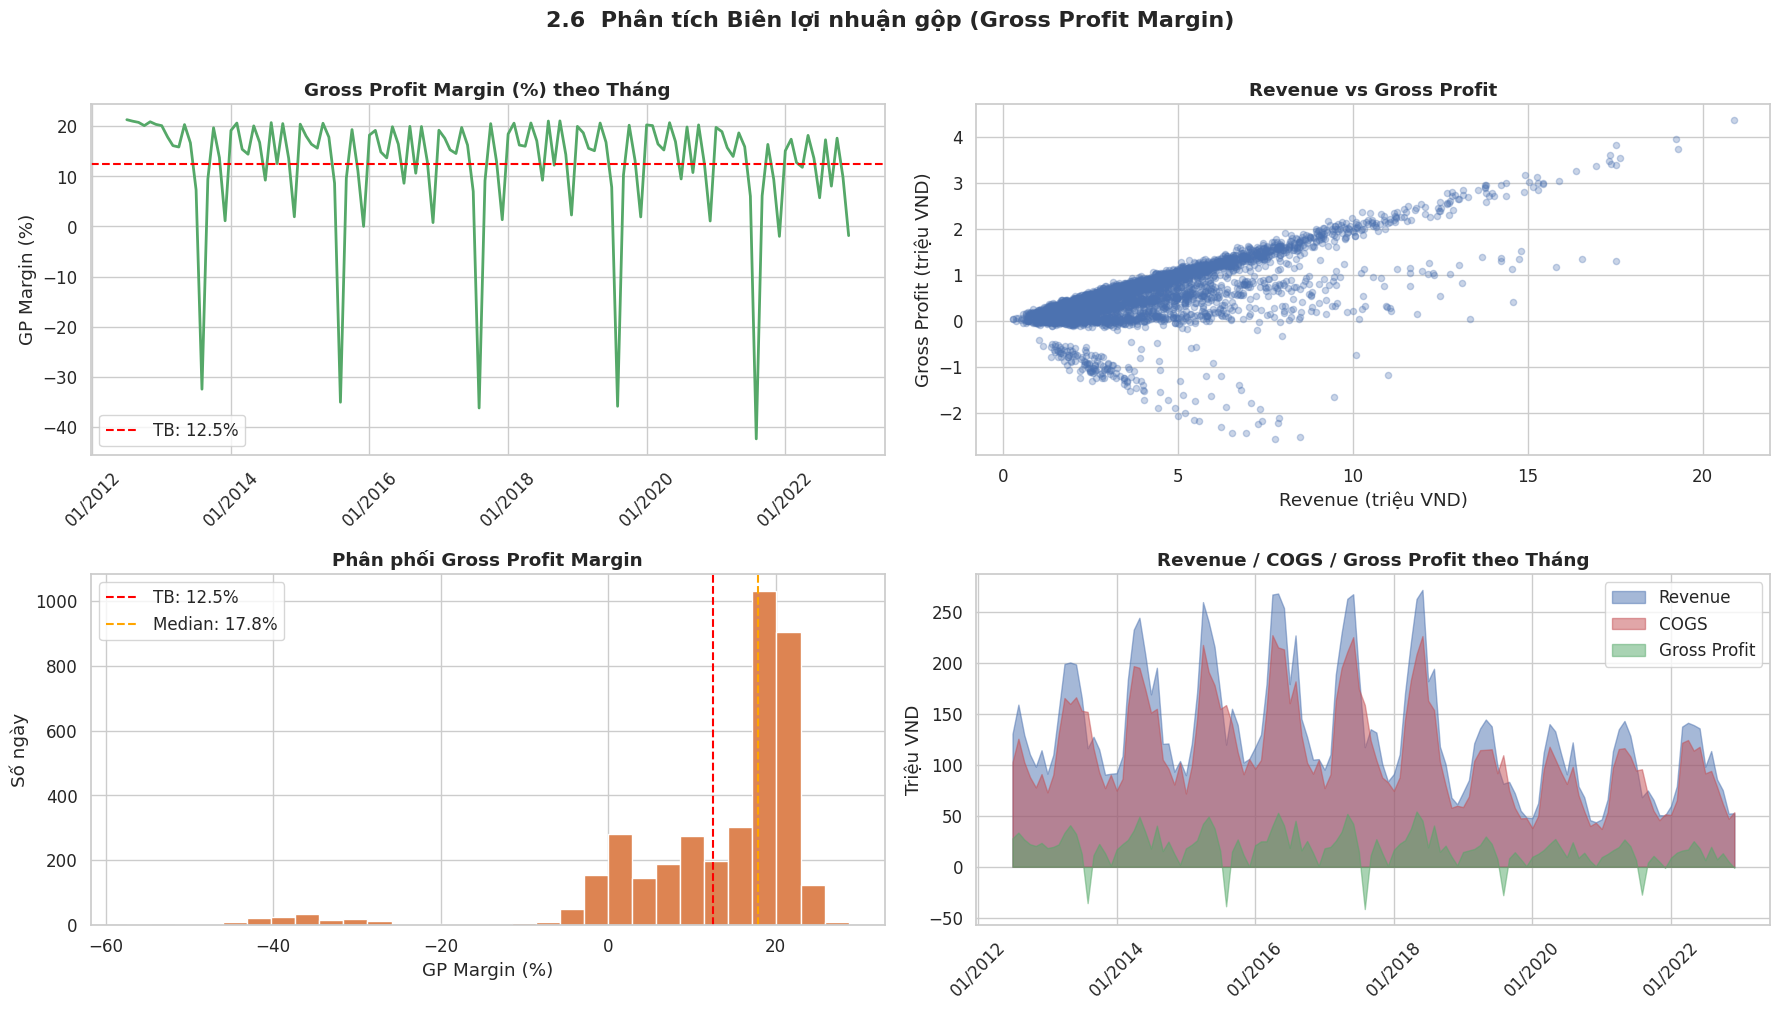

GP Margin TB    : 12.5%
GP Margin Min   : -57.5%  |  Max: 28.7%
Số ngày GP âm   : 382


In [18]:
# 2.6  Gross Profit Margin Analysis
df['gp_margin']  = df['gross_profit'] / df['Revenue'] * 100
df['cogs_ratio'] = df['COGS']         / df['Revenue'] * 100
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# (a) GP Margin theo tháng
ax = axes[0, 0]
monthly_gpm = df.groupby(df['date'].dt.to_period('M'))['gp_margin'].mean().reset_index()
monthly_gpm['date'] = monthly_gpm['date'].dt.to_timestamp()
ax.plot(monthly_gpm['date'], monthly_gpm['gp_margin'], color=PALETTE[2], linewidth=2)
ax.axhline(df['gp_margin'].mean(), color='red', linestyle='--',
           label=f"TB: {df['gp_margin'].mean():.1f}%")
ax.set_title("Gross Profit Margin (%) theo Tháng", fontweight='bold')
ax.set_ylabel("GP Margin (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
# (b) Revenue vs Gross Profit
ax = axes[0, 1]
ax.scatter(df['Revenue'] / 1e6, df['gross_profit'] / 1e6,
           alpha=0.3, color=PALETTE[0], s=20)
ax.set_xlabel("Revenue (triệu VND)"); ax.set_ylabel("Gross Profit (triệu VND)")
ax.set_title("Revenue vs Gross Profit", fontweight='bold')

# (c) Histogram GP Margin
ax = axes[1, 0]
ax.hist(df['gp_margin'], bins=30, color=PALETTE[1], edgecolor='white')
ax.axvline(df['gp_margin'].mean(),   color='red',    linestyle='--',
           label=f"TB: {df['gp_margin'].mean():.1f}%")
ax.axvline(df['gp_margin'].median(), color='orange', linestyle='--',
           label=f"Median: {df['gp_margin'].median():.1f}%")
ax.set_xlabel("GP Margin (%)"); ax.set_ylabel("Số ngày")
ax.set_title("Phân phối Gross Profit Margin", fontweight='bold')
ax.legend()
# (d) Revenue / COGS / Gross Profit stacked area
ax = axes[1, 1]
ms = df.groupby(df['date'].dt.to_period('M'))[['Revenue','COGS','gross_profit']].sum().reset_index()
ms['date'] = ms['date'].dt.to_timestamp()
ax.fill_between(ms['date'], ms['Revenue'] / 1e6,
                label='Revenue', alpha=0.5, color=PALETTE[0])
ax.fill_between(ms['date'], ms['COGS'] / 1e6,
                label='COGS', alpha=0.5, color=PALETTE[3])
ax.fill_between(ms['date'], ms['gross_profit'] / 1e6,
                label='Gross Profit', alpha=0.5, color=PALETTE[2])
ax.set_ylabel("Triệu VND")
ax.set_title("Revenue / COGS / Gross Profit theo Tháng", fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.suptitle("2.6  Phân tích Biên lợi nhuận gộp (Gross Profit Margin)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f"GP Margin TB    : {df['gp_margin'].mean():.1f}%")
print(f"GP Margin Min   : {df['gp_margin'].min():.1f}%  |  Max: {df['gp_margin'].max():.1f}%")
print(f"Số ngày GP âm   : {(df['gross_profit'] < 0).sum()}")
